In [2]:
import os
import pickle
from tqdm.notebook import tqdm
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium.wrappers import RecordVideo, RecordEpisodeStatistics
import gym_snakegame
from rewards import SnakeRewardWrapper
from IPython.display import Video, display
from ipywidgets import interact

VIDEO_DIR = Path("final_results/videos")
VIDEO_DIR.mkdir(parents=True, exist_ok=True)
os.makedirs("final_results/data", exist_ok=True)

In [3]:
def get_allocentric_state(env):
    snake = env.unwrapped.snake
    if len(snake) == 0: return (0,)*11
    
    board = env.unwrapped.board
    head = snake[-1]
    target_val = env.unwrapped.ITEM
    bs = env.unwrapped.board_size
    target_pos = np.argwhere(board == target_val)[0]

    def is_unsafe(pos):
        r, c = pos
        if not (0 <= r < bs and 0 <= c < bs): return True
        return 0 < board[r, c] < target_val

    return (
        is_unsafe((head[0]-1, head[1])), is_unsafe((head[0]+1, head[1])),
        is_unsafe((head[0], head[1]-1)), is_unsafe((head[0], head[1]+1)),
        target_pos[0] < head[0], target_pos[0] > head[0],
        target_pos[1] < head[1], target_pos[1] > head[1],
        env.unwrapped.prev_action == 0, env.unwrapped.prev_action == 1,
        env.unwrapped.prev_action == 2
    )

def get_egocentric_state(env):
    snake = env.unwrapped.snake
    if len(snake) == 0: return (0,)*6
        
    board = env.unwrapped.board
    head = snake[-1]
    target_val = env.unwrapped.ITEM
    bs = env.unwrapped.board_size
    target_pos = np.argwhere(board == target_val)[0]
    prev_action = env.unwrapped.prev_action 

    dirs = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
    curr_dir = dirs.get(prev_action, (0, 1)) 

    forward = curr_dir
    left = (-curr_dir[1], curr_dir[0])
    right = (curr_dir[1], -curr_dir[0])

    def is_unsafe(offset):
        r, c = head[0] + offset[0], head[1] + offset[1]
        if not (0 <= r < bs and 0 <= c < bs): return True
        return 0 < board[r, c] < target_val

    danger_straight = is_unsafe(forward)
    danger_left = is_unsafe(left)
    danger_right = is_unsafe(right)

    food_vec = (target_pos[0] - head[0], target_pos[1] - head[1])
    food_forward = np.sign(food_vec[0]*forward[0] + food_vec[1]*forward[1])
    food_lateral = np.sign(food_vec[0]*right[0] + food_vec[1]*right[1])

    return (danger_straight, danger_left, danger_right, food_forward, food_lateral, prev_action)

In [4]:
def deterministic_policy(state_key, q_table):
    q_values = [q_table.get((state_key, a), 0.0) for a in range(4)]
    return np.argmax(q_values)

# Evaluation Methodology
The models are tested across 100 episodes with $\epsilon = 0$ (greedy policy). Performance is quantified via:
* **Average Return:** Cumulative reward efficiency.
* **Steps per Food:** Pathfinding optimality.
* **Peak Length:** Survival and growth capability.

# Generalization Gap Analysis
To test the robustness of the learned policies, we deploy agents trained on a $10 \times 10$ grid into a $20 \times 20$ environment.

In [5]:
experiments = ["Dense_Standard", "Sparse_Experimental", "Survivalist_Safe"]
state_types = ["Allocentric", "Egocentric"]
grids = {"10x10": 10, "20x20": 20}
EVAL_EPISODES = 100
MAX_STEPS = 1000 

all_results = []

for state_type in state_types:
    for exp in experiments:
        agent_name = f"{state_type}_{exp}"
        reward_type = exp.split("_")[0].lower()
        system_label = exp.split("_")[0]
        
        state_func = get_allocentric_state if state_type == "Allocentric" else get_egocentric_state
        
        model_path = f"final_results/models/{agent_name}_q_table.pkl"
        try:
            with open(model_path, "rb") as f:
                q_table = pickle.load(f)
        except FileNotFoundError:
            print(f"Skipping {agent_name}: model not found.")
            continue

        for grid_name, size in grids.items():
            base_env = gym.make("gym_snakegame/SnakeGame-v0", board_size=size)
            env = SnakeRewardWrapper(base_env, system_type=reward_type)

            ep_metrics = []
            progress_desc = f"Evaluating {agent_name} on {grid_name}"
            
            for _ in tqdm(range(EVAL_EPISODES), desc=progress_desc, leave=False):
                obs, info = env.reset()
                state_key = str(state_func(env))
                done = False
                steps, food_consumed, total_return = 0, 0, 0 
                
                while not done:
                    action = deterministic_policy(state_key, q_table)
                    _, reward, terminated, truncated, info = env.step(action)
                    state_key = str(state_func(env))
                    
                    total_return += reward
                    steps += 1
                    
                    if (reward_type != "survivalist" and reward == 10.0) or \
                       (reward_type == "survivalist" and reward == 5.0):
                        food_consumed += 1
                        
                    done = terminated or truncated or (steps >= MAX_STEPS)

                final_length = info.get('snake_length', 3)
                ep_metrics.append({
                    "return": total_return,
                    "length": final_length,
                    "steps": steps,
                    "food": food_consumed,
                    "success": 1 if final_length > 10 else 0
                })

            df_ep = pd.DataFrame(ep_metrics)
            
            all_results.append({
                "Agent": agent_name,
                "System": system_label,
                "State": state_type,
                "Grid": grid_name,
                "Avg Return": df_ep["return"].mean(),
                "Peak Length": df_ep["length"].max(),
                "Steps/Food": df_ep["steps"].sum() / max(1, df_ep["food"].sum()),
                "Success (%)": df_ep["success"].mean() * 100
            })
            env.close()

df_all = pd.DataFrame(all_results)

print("\nTABLE 2: 10x10 EVALUATION METRICS")
table2 = df_all[df_all["Grid"] == "10x10"][["System", "State", "Avg Return", "Peak Length", "Steps/Food", "Success (%)"]]
display(table2.sort_values(["State", "System"]))

print("\nTABLE 3: GENERALIZATION GAP (10x10 vs 20x20)")
table3 = df_all.pivot_table(index=["System", "State"], columns="Grid", values="Avg Return").reset_index()
table3.columns.name = None
table3 = table3.rename(columns={"10x10": "10x10 Return", "20x20": "20x20 Return"})

table3["Gap (%)"] = ((table3["10x10 Return"] - table3["20x20 Return"]) / table3["10x10 Return"]) * 100

display(table3.sort_values("Gap (%)"))

df_all.to_csv("final_results/data/formal_evaluation_statistics.csv", index=False)

/home/yarina/venvs/torch/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Evaluating Allocentric_Dense_Standard on 10x10:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating Allocentric_Dense_Standard on 20x20:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating Allocentric_Sparse_Experimental on 10x10:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating Allocentric_Sparse_Experimental on 20x20:   0%|          | 0/100 [00:00<?, ?it/s]

...

Evaluating Egocentric_Survivalist_Safe on 20x20:   0%|          | 0/100 [00:00<?, ?it/s]


TABLE 2: 10x10 EVALUATION METRICS


,System,State,Avg Return,Peak Length,Steps/Food,Success (%)
0,Dense,Allocentric,73.8398,23,17.189125,51.0
2,Sparse,Allocentric,149.1000,32,10.676933,94.0
4,Survivalist,Allocentric,85.0460,34,26.509913,88.0
6,Dense,Egocentric,57.1510,24,13.683900,39.0
8,Sparse,Egocentric,62.8000,23,9.104396,42.0
10,Survivalist,Egocentric,35.7085,28,10.223310,62.0



TABLE 3: GENERALIZATION GAP (10x10 vs 20x20)


,System,State,10x10 Return,20x20 Return,Gap (%)
5,Survivalist,Egocentric,35.7085,103.8100,-190.715096
1,Dense,Egocentric,57.1510,112.5275,-96.895067
4,Survivalist,Allocentric,85.0460,146.6570,-72.444324
2,Sparse,Allocentric,149.1000,254.7000,-70.824950
3,Sparse,Egocentric,62.8000,106.2000,-69.108280
0,Dense,Allocentric,73.8398,90.1277,-22.058429


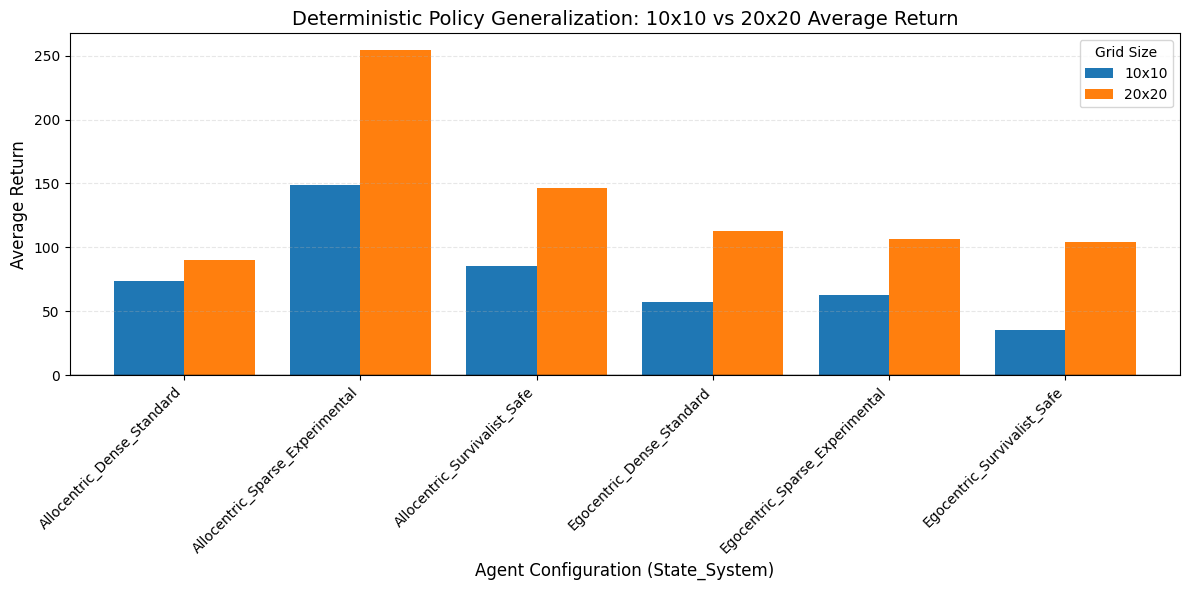

In [7]:
df_plot = df_all.pivot(index="Agent", columns="Grid", values="Avg Return")

cols_to_plot = ["10x10", "20x20"]
df_plot = df_plot[cols_to_plot]

df_plot.plot(kind="bar", figsize=(12, 6), width=0.8, color=['#1f77b4', '#ff7f0e'])

plt.title("Deterministic Policy Generalization: 10x10 vs 20x20 Average Return", fontsize=14)
plt.ylabel("Average Return", fontsize=12)
plt.xlabel("Agent Configuration (State_System)", fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title="Grid Size")
plt.tight_layout()

plt.savefig("final_results/plots/generalization_comparison.png")
plt.show()

In [8]:
VIDEO_DIR = Path("final_results/videos")
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

experiments = ["Dense_Standard", "Sparse_Experimental", "Survivalist_Safe"]
state_types = ["Allocentric", "Egocentric"]
grids = {"10x10": 10, "20x20": 20}
VIS_EPISODES = 1  # how many episodes to record per agent/grid
MAX_STEPS = 1000

all_video_paths = {}

for state_type in state_types:
    for exp in experiments:
        agent_name = f"{state_type}_{exp}"
        reward_type = exp.split("_")[0].lower()
        state_func = get_allocentric_state if state_type == "Allocentric" else get_egocentric_state
        
        model_path = f"final_results/models/{agent_name}_q_table.pkl"
        if not os.path.exists(model_path):
            continue
            
        with open(model_path, "rb") as f:
            q_table = pickle.load(f)

        for grid_name, size in grids.items():
            video_prefix = f"{agent_name}_{grid_name}"
            
            base_env = gym.make("gym_snakegame/SnakeGame-v0", board_size=size, render_mode="rgb_array")
            
            env = RecordVideo(
                base_env, 
                video_folder=str(VIDEO_DIR), 
                name_prefix=video_prefix,
                episode_trigger=lambda x: True 
            )
            
            env = SnakeRewardWrapper(env, system_type=reward_type)

            for episode_index in range(VIS_EPISODES):
                obs, info = env.reset()
                state_key = str(state_func(env))
                done = False
                steps = 0
                
                while not done and steps < MAX_STEPS:
                    action = deterministic_policy(state_key, q_table)
                    _, _, terminated, truncated, info = env.step(action)
                    state_key = str(state_func(env))
                    
                    steps += 1
                    done = terminated or truncated

                video_file = VIDEO_DIR / f"{video_prefix}-episode-{episode_index}.mp4"
                all_video_paths[f"{agent_name} | {grid_name}"] = str(video_file)
            
            env.close()

def video_selector(Trajectory):
    if Trajectory:
        return Video(Trajectory, embed=True, html_attributes="controls loop autoplay", width=500)

print("\nSelect the agent and grid size to visualize the learned policy:")
interact(video_selector, Trajectory=all_video_paths);

/home/yarina/venvs/torch/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/yarina/snakegame/final_results/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/home/yarina/venvs/torch/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/yarina/snakegame/final_results/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(



Select the agent and grid size to visualize the learned policy:


interactive(children=(Dropdown(description='Trajectory', options={'Allocentric_Dense_Standard | 10x10': 'final…